### Figure 4F. Does long theta or remote theta content help animal correct switch-side bias?

Jan 21, 2026

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import xarray as xr
from scipy import stats
from scipy import linalg
import os
import pickle
import matplotlib.pyplot as plt

In [3]:
from spyglass.shijiegu.changeOfMind_figures.figure4 import (long_theta_count_per_day, intersection,
            return_com_theta_length_remote_feature)
from spyglass.shijiegu.changeOfMind_figures.figure4d import find_choice_animal, trial_to_features
from spyglass.shijiegu.Analysis_SGU import ChangeofMind

from spyglass.shijiegu.changeOfMind import nodes
from spyglass.shijiegu.decodeHelpers import session2position_name
from spyglass.shijiegu.changeOfMind_remote import do_GLM_subprocess

from spyglass.shijiegu.changeOfMind_remote_interval import save_remote_animal, load_remote_animal

from spyglass.shijiegu.changeOfMind_triggered import (seq2, rev2, rev3, seq1, rev1)

[2026-01-21 10:47:59,535][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306
[10:48:11][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[10:48:11][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[10:48:11][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[10:48:12][WARNING] Spyglass: Deprecation: this class has b

In [4]:
list_of_days_animals, learning_flag, encoding_set_animals, classifier_param_name_animals, seq_animals = {}, {}, {}, {}, {}

In [23]:
animal = "molly"
list_of_days_animals[animal]  = ['20220416','20220417','20220418','20220419','20220420']
learning_flag[animal] = [1,1,1,1,0] #denote for each day, if it is a learning day
seq_animals[animal] = seq2

animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109','20240110']
learning_flag[animal] = [1,1,1,1,1,0] #denote for each day, if it is a learning day
seq_animals[animal] = rev2

animal = "eliot"
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
learning_flag[animal] = [1,1,1,1,1,1,0,0,0] #denote for each day, if it is a learning day
seq_animals[animal] = seq2

animal = 'julio'
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']
learning_flag[animal] = [1 for d in ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806']] #denote for each day, if it is a learning day
learning_flag[animal] += [0 for d in ['20230807','20230808','20230809','20230810','20230811']]
seq_animals[animal] = seq2

animal = 'klein'
list_of_days_animals[animal]  = ['20231101','20231102','20231103','20231104','20231105',#
                 '20231106','20231107','20231108']
learning_flag[animal] = [1 for d in ['20231101','20231102','20231103','20231104','20231105',#
                 '20231106','20231107']]
learning_flag[animal] += [0 for d in ['20231108']]

seq_animals[animal] = rev2

### Simple conditioning

In [22]:
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.shijiegu.decodeHelpers import runSessionNames
from spyglass.shijiegu.Analysis_SGU import ChangeofMindTheta, ChangeofMindRemoteTheta

from scipy.stats import ranksums
from scipy.stats import fisher_exact
import starbars
import statsmodels.api as sm


def get_savename(animal, output_folder, parameter_name_remote, minimum_duration_long, minimum_duration_remote, min_posterior,sd):
    output_path = os.path.join(output_folder,f"{animal}_{parameter_name_remote}_{minimum_duration_long}_{minimum_duration_remote}_{min_posterior}_sd{sd}_figure4Fd") #os.join(output_folder,plot_data_filename)
    return output_path

In [8]:
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'

In [9]:
ChangeofMindTheta()

nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),proportion minimal amount of proportion the animal is in before it backed out,parameter parameter name,"local_parameter time in seconds, the min duration of an event","pandas pandas dataframe saved as dictionary, choice"
eliot20221018_.nwb,2,0.1,params_both_max_segment_run_time_2_state,dur_0.03_sd_6_hpdFalse,=BLOB=
eliot20221018_.nwb,2,0.1,params_both_max_segment_run_time_2_state,dur_0.03_sd_6_hpdTrue,=BLOB=
eliot20221018_.nwb,5,0.1,params_both_max_segment_run_time_2_state,dur_0.03_sd_6_hpdFalse,=BLOB=
eliot20221018_.nwb,5,0.1,params_both_max_segment_run_time_2_state,dur_0.03_sd_6_hpdTrue,=BLOB=
eliot20221018_.nwb,7,0.1,params_both_max_segment_run_time_2_state,dur_0.03_sd_6_hpdFalse,=BLOB=
eliot20221018_.nwb,7,0.1,params_both_max_segment_run_time_2_state,dur_0.03_sd_6_hpdTrue,=BLOB=
eliot20221018_.nwb,9,0.1,params_both_max_segment_run_time_2_state,dur_0.03_sd_6_hpdFalse,=BLOB=
eliot20221018_.nwb,9,0.1,params_both_max_segment_run_time_2_state,dur_0.03_sd_6_hpdTrue,=BLOB=
eliot20221018_.nwb,11,0.1,params_both_max_segment_run_time_2_state,dur_0.03_sd_6_hpdFalse,=BLOB=
eliot20221018_.nwb,11,0.1,params_both_max_segment_run_time_2_state,dur_0.03_sd_6_hpdTrue,=BLOB=


In [20]:
def has_remote_theta(df,trialID):
    if len(df) == 0:
        return False
    remote_interval = df.loc[trialID,'remote_interval']
    initial_stopping = df.loc[trialID,'initial_time']
                
    post_ind = [ind for ind in range(len(remote_interval)) if remote_interval[ind][0] >= initial_stopping]
    
    if len(post_ind) > 0:
        return True
    else:
        return False

def has_outer_remote_theta(df,trialID):
    if len(df) == 0:
        return False
    remote_interval = df.loc[trialID,'remote_interval']
    remote_content = df.loc[trialID,'remote_content']
    initial_stopping = df.loc[trialID,'initial_time']
                
    post_ind = [ind for ind in range(len(remote_interval)) if remote_interval[ind][0] >= initial_stopping]
    if len(post_ind) == 0:
        return False
        
    remote_content = [remote_content[ind] for ind in post_ind]

    if len(np.setdiff1d(remote_content, [0])) > 0:
        return True
    else:
        return False

def has_home_remote_theta(df,trialID):
    if len(df) == 0:
        return False
    remote_interval = df.loc[trialID,'remote_interval']
    remote_content = df.loc[trialID,'remote_content']
    initial_stopping = df.loc[trialID,'initial_time']
                
    post_ind = [ind for ind in range(len(remote_interval)) if remote_interval[ind][0] >= initial_stopping]
    if len(post_ind) == 0:
        return False
        
    remote_content = [remote_content[ind] for ind in post_ind]

    if np.isin(0,remote_content):
        return True
    else:
        return False

def has_long_theta(df,trialID):
    if len(df) == 0:
        return False
    long_interval = df.loc[trialID,'long_theta_intervals']
    initial_stopping = df.loc[trialID,'initial_time']
                
    post_ind = [ind for ind in range(len(long_interval)) if long_interval[ind][0] >= initial_stopping]
    
    if len(post_ind) > 0:
        return True
    else:
        return False

same_side_dict = {1:[1,2],2:[1,2],3:[3,4],4:[3,4]}
def same_side(arm1, arm2):
    arm1 = int(arm1)
    arm2 = int(arm2)
    return np.isin(arm2, same_side_dict[arm1])

def correct_sequence(arm1, arm2, seq):
    return int(seq[arm1]) == arm2

In [32]:
success = {}

#parameter_name_long_theta = "params_both_max_segment_all_maze_2_state"
#parameter_name_remote = "params_both_max_all_maze_2_state"#"params_both_max_run_time_2_state" #"params_both_max_all_maze_2_state"  #"params_both_max_run_time_2_state"

parameter_name_long_theta = "params_both_max_segment_run_time_2_state"
parameter_name_remote = "params_both_max_run_time_2_state"
minimum_duration_long = 0.03
minimum_duration_remote = 0.02
min_posterior = 0.4
sd = 6
hpd = False

for animal in ["molly","klein","eliot","julio","lewis"]:
    # trials with either long theta or remote theta
    
    # loop through all trials
    list_of_days = list_of_days_animals[animal]
    learning_flag_days = learning_flag[animal]
    
    reward = []
    theta = []
    long_theta = []
    remote_theta = []
    remote_theta_outer = []
    remote_theta_home = []
    com_num = []
    learning = []
    max_distance = []
    
    
    for day_ind in range(len(list_of_days)):
        day = list_of_days[day_ind]
        learning_flag_day = learning_flag_days[day_ind]
        
        nwb_file_name = animal.lower() + day + '.nwb'
        nwb_copy_file_name = get_nwb_copy_filename(nwb_file_name)
        print(nwb_copy_file_name)
        session_interval, position_interval = runSessionNames(nwb_copy_file_name)
            
        q_long = {"proportion": 0.1,
                 "minimum_duration":minimum_duration_long,
                  "parameter":parameter_name_long_theta,
                  "local_parameter":f"dur_{minimum_duration_long}_sd_{sd}_hpd{hpd}"
                 }

        q_long["nwb_file_name"] = nwb_copy_file_name
        q_remote = q_long.copy()
        q_remote["parameter"] = parameter_name_remote
        q_remote["minimum_duration"] = minimum_duration_remote
        q_remote["remote_parameter"] = f"dur_{minimum_duration_remote}_sum_{min_posterior}" #f"parameter_name_remote
    
        for session_name in session_interval:
            q_long["epoch"] = int(session_name[:2])
            q_remote["epoch"] = int(session_name[:2])
            
            if len(ChangeofMindTheta() & q_long) > 0:
                long_df = ChangeofMindTheta().fetch1_dataframe(q_long)         # trials with long theta
            else:
                long_df = []

            if len(ChangeofMindRemoteTheta() & q_remote) > 0:
                remote_df = ChangeofMindRemoteTheta().fetch1_dataframe(q_remote) # trials with remote theta for now
            else:
                remote_df = []
    
            # change of mind trials
            df = ChangeofMind().fetch1_dataframe(q_remote)
            theta_df_subset = df[df.change_of_mind]
    
            for trialID in theta_df_subset.index:
                # check if a trial has multiple change-of-mind
                # if df.loc[trialID].CoMNum_by_arm > 1 or df.loc[trialID].CoMNum_by_time > 1:
                #     continue

                if trialID == 1:
                    continue
                    
                # find change of mind number on this trial
                com_num.append(df.loc[trialID].CoMNum_by_arm)

                # find other information
                reward.append(
                    correct_sequence(df.loc[trialID-1].OuterWellIndex,
                                     df.loc[trialID].OuterWellIndex, seq_animals[animal])
                    #same_side(df.loc[trialID].OuterWellIndex, df.loc[trialID-1].OuterWellIndex)
                )
                
                
                if has_remote_theta(remote_df,trialID):
                    print("remote_content",remote_df.loc[trialID].remote_content)
                    remote_flag = True
                    remote_theta.append(1)
                else:
                    remote_flag = False
                    remote_theta.append(0)

                if has_outer_remote_theta(remote_df,trialID):
                    remote_flag_exlude_home = True
                    remote_theta_outer.append(1)
                else:
                    remote_flag_exlude_home = False
                    remote_theta_outer.append(0)

                if has_long_theta(long_df,trialID):
                    long_theta.append(1)
                else:
                    long_theta.append(0)

                if remote_flag or long_theta[-1] == 1:
                    theta.append(1)
                else:
                    theta.append(0)

                if has_home_remote_theta(remote_df,trialID):
                    remote_theta_home.append(1)
                else:
                    remote_theta_home.append(0)

                learning.append(learning_flag_day)
                max_distance.append(df.loc[trialID].CoMMaxProportion)


    data = {}
    data["reward"] = reward
    data["remote_theta"] = remote_theta #np.array(remote_theta_home) + np.array(remote_theta_outer)
    data["long_theta"] = long_theta
    data["theta"] = theta
    data["com_num"] = com_num
    data["learning_flag"] = learning
    data["max_distance"] = max_distance
    data["remote_theta_home"] = remote_theta_home
    data["remote_theta_outer"] = remote_theta_outer
    
    output_path = get_savename(animal, output_folder, parameter_name_remote, q_long["local_parameter"], minimum_duration_remote, min_posterior, sd)
    with open(output_path, 'wb') as file:
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
        print(f"Data successfully pickled and saved.")
        
    success[animal] = 1


molly20220416_.nwb
molly20220417_.nwb
remote_content [4, 4, 4, 4, 4]
remote_content [3]
remote_content [4, 4]
remote_content [4, 0, 0, 4, 4, 4]
molly20220418_.nwb
remote_content [4]
remote_content [4]
remote_content [4, 4]
remote_content [4]
remote_content [0, 0]
remote_content [4]
remote_content [1]
remote_content [4, 4]
molly20220419_.nwb
remote_content [0]
remote_content [4]
remote_content [4]
remote_content [3]
remote_content [1]
molly20220420_.nwb
remote_content [2, 2]
remote_content [0]
remote_content [2]
remote_content [0]
remote_content [0, 0]
Data successfully pickled and saved.
klein20231101_.nwb
remote_content [1, 3]
remote_content [3, 4, 3]
remote_content [3]
remote_content [4, 4, 4]
remote_content [2]
remote_content [3]
remote_content [3]
remote_content [3]
remote_content [0]
remote_content [4, 3]
remote_content [3, 3]
remote_content [4, 4]
remote_content [2, 2, 2]
remote_content [3]
remote_content [0]
remote_content [2]
remote_content [3]
remote_content [4]
remote_content

### with all theta

In [28]:
from scipy.stats import ranksums
from scipy.stats import fisher_exact
import starbars
import statsmodels.api as sm

In [29]:
color_by_rat = {"eliot": "C0","molly":"C2","lewis":"C4","julio":"C1","klein":"deepskyblue"}

def sd_err(arr):
    return np.std(arr)/np.sqrt(len(arr))

def plot_one_axis(data1, data2, animal_ind, ax, animal, draw_annotation = False):
    std = [sd_err(data1), sd_err(data2)]
    mean = [np.mean(data1), np.mean(data2)]
    ax.bar([0 + animal_ind,
                0.3 + animal_ind],mean, yerr=std, width=0.2, hatch=['', '////'],color = color_by_rat[animal])
    ax.text(animal_ind - 0.15, mean[0]+std[0] + 0.1, len(data1), fontsize = 6)
    ax.text(animal_ind + 0.3 - 0.15, mean[1]+std[1] + 0.1, len(data2), fontsize = 6)
        
    table = np.array([[np.sum(data1 == 0), np.sum(data1 == 1)],[np.sum(data2 == 0), np.sum(data2 == 1)]])
    res = fisher_exact(table)
    p_value = res.pvalue
    if p_value < 0.05 and draw_annotation:
        starbars.draw_annotation([(animal_ind, animal_ind + 0.3, np.round(p_value, 4))], ax = ax)
    return ax, p_value



In [33]:
#parameter_name_long_theta = "params_both_max_segment_all_maze_2_state"
#parameter_name_remote = "params_both_max_all_maze_2_state"#"params_both_max_run_time_2_state" #"params_both_max_all_maze_2_state"  #"params_both_max_run_time_2_state"

parameter_name_long_theta = "params_both_max_segment_run_time_2_state"
parameter_name_remote = "params_both_max_run_time_2_state"
minimum_duration_long = 0.03
minimum_duration_remote = 0.02
min_posterior = 0.4
sd = 6
hpd = False

local_parameter = f"dur_{minimum_duration_long}_sd_{sd}_hpd{hpd}"

#parameter_name = "params_both_max_run_time_2_state"#"params_both_max_run_time_2_state" #"params_both_max_all_maze_2_state"  #"params_both_max_run_time_2_state"

In [34]:
def draw_annotation(ijps,ax,height = 0.9):
    for ijp in ijps:
        x1, x2, p = ijp
        if p <= 0.001:
            label = "***"
        elif p <= 0.01:
            label = "**"
        elif p <= 0.05:
            label = "*"
        ax.text(np.mean([x1,x2]), height, label)



Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/lewis_params_both_max_run_time_2_state_dur_0.03_sd_6_hpdFalse_0.02_0.4_sd6_figure4Fd
pvalue lewis row number 0 0.35433814422578336
pvalue lewis row number 1 0.37228169643533904
pvalue lewis row number 2 1.0
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/eliot_params_both_max_run_time_2_state_dur_0.03_sd_6_hpdFalse_0.02_0.4_sd6_figure4Fd
pvalue eliot row number 0 0.25199868067464926
pvalue eliot row number 1 0.2657887976177826
pvalue eliot row number 2 1.0
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/molly_params_both_max_run_time_2_state_dur_0.03_sd_6_hpdFalse_0.02_0.4_sd6_figure4Fd
pvalue molly row number 0 0.06085968965760111
pvalue molly row number 1 0.13161055014439063
pvalue molly row number 2 0.296858747659663
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/klein_params_both_max_run_time_2_state_dur_0.03_sd_6_hpdFa

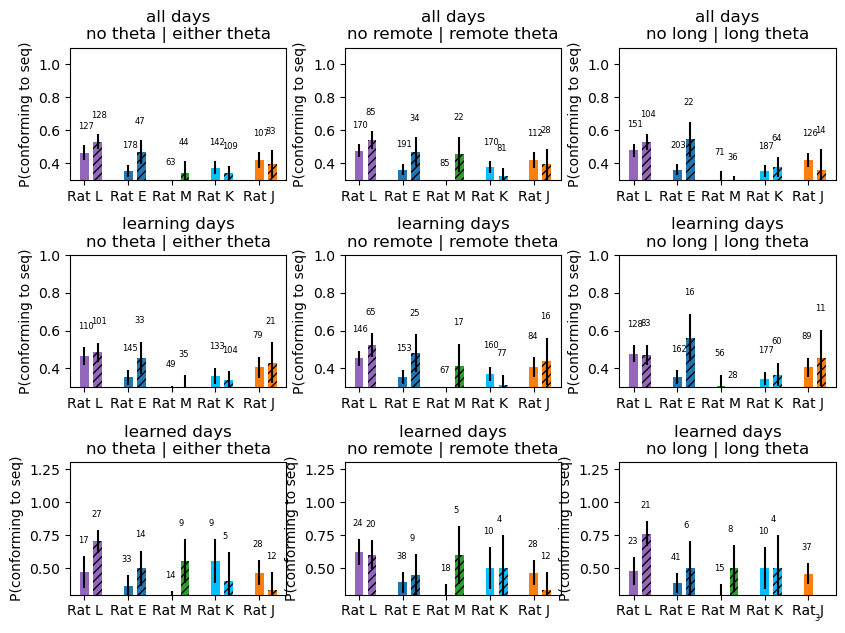

In [35]:
num_of_panels = 3
fig, axes = plt.subplots(3, num_of_panels, figsize=(3 * num_of_panels, 7))#sharey = True)

animal_ind = 0
animals = ["lewis","eliot","molly","klein","julio"]#["molly","eliot","julio","lewis","klein"]#["molly","lewis","julio","klein"]

annotations = {(i,j):[] for j in range(3) for i in range(3)}

for animal in animals:

    output_path = get_savename(animal, output_folder, parameter_name_remote, local_parameter, minimum_duration_remote, min_posterior, sd)
    with open(output_path, 'rb') as file:
        loaded_data = pickle.load(file)
        print(f"Data successfully loaded from {output_path}")

    (reward, remote_theta, long_theta, theta, com_num, learning) = (
        loaded_data["reward"],
        loaded_data["remote_theta"], loaded_data["long_theta"], loaded_data["theta"],
        loaded_data["com_num"], loaded_data["learning_flag"])

    for axes_row_ind in [0,1,2]: #all data, learning days, post-learning days
        
        if axes_row_ind == 0:
            reward_theta = np.array(reward)[np.array(theta) > 0]
            reward_nontheta = np.array(reward)[(1-np.array(theta)) > 0]
            reward_remote_theta = np.array(reward)[np.array(remote_theta) > 0]
            reward_nonremote_theta = np.array(reward)[1-np.array(remote_theta) > 0]
            reward_long_theta = np.array(reward)[np.array(long_theta) > 0]
            reward_nonlong_theta = np.array(reward)[1-np.array(long_theta) > 0]
        elif axes_row_ind == 1:
            learning = np.array(learning)
            reward_theta = np.array(reward)[np.logical_and(np.array(theta) > 0, learning)]
            reward_nontheta = np.array(reward)[np.logical_and((1-np.array(theta)) > 0, learning)]
            reward_remote_theta = np.array(reward)[np.logical_and(np.array(remote_theta) > 0, learning)]
            reward_long_theta = np.array(reward)[np.logical_and(np.array(long_theta) > 0, learning)]
            reward_nonremote_theta = np.array(reward)[np.logical_and((1-np.array(remote_theta)) > 0, learning)]
            reward_nonlong_theta = np.array(reward)[np.logical_and((1-np.array(long_theta)) > 0, learning)]
        elif axes_row_ind == 2:
            nonlearning = 1 - np.array(learning)
            reward_theta = np.array(reward)[np.logical_and(np.array(theta) > 0, nonlearning)]
            reward_nontheta = np.array(reward)[np.logical_and((1-np.array(theta)) > 0, nonlearning)]
            reward_remote_theta = np.array(reward)[np.logical_and(np.array(remote_theta) > 0, nonlearning)]
            reward_long_theta = np.array(reward)[np.logical_and(np.array(long_theta) > 0, nonlearning)]
            reward_nonremote_theta = np.array(reward)[np.logical_and((1-np.array(remote_theta)) > 0, nonlearning)]
            reward_nonlong_theta = np.array(reward)[np.logical_and((1-np.array(long_theta)) > 0, nonlearning)]
            

        # axis 1: nontheta vs theta
        ax = axes[axes_row_ind,0]
        data1, data2 = reward_nontheta, reward_theta
        _, pvalue = plot_one_axis(data1, data2, animal_ind, ax, animal)
        #_, pvalue = ranksums(data1, data2)
        if pvalue <= 0.05:
            annotations[(axes_row_ind,0)].append((0 + animal_ind, 0.3 + animal_ind, pvalue))
    
        # axis 2: nontheta vs theta
        ax = axes[axes_row_ind,1]
        data1, data2 = reward_nonremote_theta, reward_remote_theta
        _, pvalue = plot_one_axis(data1, data2, animal_ind, ax, animal)
        #_, pvalue = ranksums(data1, data2, "less")
        print("pvalue", animal, "row number", axes_row_ind, pvalue)
        if pvalue <= 0.05:
            annotations[(axes_row_ind,1)].append((0 + animal_ind, 0.3 + animal_ind, pvalue))

        # axis 3: nontheta vs long theta
        ax = axes[axes_row_ind,2]
        data1, data2 = reward_nonlong_theta, reward_long_theta
        _, pvalue = plot_one_axis(data1, data2, animal_ind, ax, animal)
        #_, pvalue = ranksums(data1, data2)
        if pvalue <= 0.05:
            annotations[(axes_row_ind,2)].append((0 + animal_ind, 0.3 + animal_ind, pvalue))

    animal_ind += 1


for i in range(3):
    for j in range(3):
        ax = axes[i,j]
        #starbars.draw_annotation(annotations[i,j],ax)
        
        
        ax.set_xticks(np.arange(len(animals)));
        ax.set_xticklabels(["Rat " + animal[0].upper() for animal in animals]);
        ax.set_ylabel("P(conforming to seq)")
        #ax.set_xlim([-1,len(animals) + 1]);
        #ax.set_ylim([0.3,0.85]);

        if j == 0:
            title = "no theta | either theta"
        elif j == 1:
            title = "no remote | remote theta"
        elif j == 2:
            title = "no long | long theta"
        if i == 0:
            title = "all days\n" + title
            draw_annotation(annotations[i,j],ax,height = 0.95)
            ax.set_ylim([0.3,1.1])
        elif i == 1:
            title = "learning days\n" + title
            draw_annotation(annotations[i,j],ax,height = 0.8)
            ax.set_ylim([0.3,1])
        elif i == 2:
            title = "learned days\n" + title
            draw_annotation(annotations[i,j],ax,height = 1.1)
            ax.set_ylim([0.3,1.3])
        
        ax.set_title(title)
        
        
    
plt.subplots_adjust(hspace=0.3)
fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 

#plt.savefig(f'extra_correctness_by_theta.pdf',dpi=300,bbox_inches='tight')

### merge all rats

#### a) either remote or local extended

In [420]:
animals = ["molly","eliot","lewis","julio","klein"]

animal_ind = 0

GLM_xy = []
for animal in animals:
    output_path = get_savename(animal, output_folder, parameter_name_remote, local_parameter, minimum_duration_remote, min_posterior, sd)
    with open(output_path, 'rb') as file:
        loaded_data = pickle.load(file)
        print(f"Data successfully loaded from {output_path}")

    (reward, remote_theta, long_theta, theta, com_num) = (
        loaded_data["reward"], loaded_data["remote_theta"], loaded_data["long_theta"], loaded_data["theta"],loaded_data["com_num"])
    learning = loaded_data["learning_flag"]
    max_distance = loaded_data["max_distance"]
    thetaxlearning = np.array(learning) * np.array(loaded_data["theta"])
    remotexlearning = np.array(learning) * np.array(loaded_data["remote_theta"])
    longxlearning = np.array(learning) * np.array(loaded_data["long_theta"])
    remote_home = loaded_data["remote_theta_home"]
    remote_outer = loaded_data["remote_theta_outer"]

    animal_category = [a == animal for a in animals]
    for ind in range(len(reward)):
        GLM_xy.append(animal_category + [
            com_num[ind],
            theta[ind], long_theta[ind], remote_theta[ind], remote_home[ind], remote_outer[ind],
            learning[ind],
            thetaxlearning[ind],
            longxlearning[ind],
            remotexlearning[ind],
            max_distance[ind],
            reward[ind]])

GLM_xy = np.array(GLM_xy)

Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/molly_params_both_max_run_time_2_state_dur_0.03_sd_6_hpdFalse_0.02_0.4_sd6_figure4Fa
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/eliot_params_both_max_run_time_2_state_dur_0.03_sd_6_hpdFalse_0.02_0.4_sd6_figure4Fa
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/lewis_params_both_max_run_time_2_state_dur_0.03_sd_6_hpdFalse_0.02_0.4_sd6_figure4Fa
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/julio_params_both_max_run_time_2_state_dur_0.03_sd_6_hpdFalse_0.02_0.4_sd6_figure4Fa
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/klein_params_both_max_run_time_2_state_dur_0.03_sd_6_hpdFalse_0.02_0.4_sd6_figure4Fa


In [421]:
## Model 1: no theta or with theta
feature_dict = {f"Rat {animals[animal_ind][0].upper()}":GLM_xy[:,animal_ind] for animal_ind in range(len(animals))}
feature_dict["theta"] = GLM_xy[:,(len(animals)+1)]
feature_dict["com num"] = GLM_xy[:,len(animals)]
#feature_dict["theta no home"] = GLM_xy[:,-4]
#feature_dict["max distance"] = GLM_xy[:,-2]
#feature_dict["learning"] = GLM_xy[:,(len(animals)+4)]
#feature_dict["theta x learning"] = GLM_xy[:,-5]
#feature_dict["theta x com"] = GLM_xy[:,(len(animals)+1)] * GLM_xy[:,len(animals)]
#feature_dict["theta x max distance"] = feature_dict["theta"] * feature_dict["max distance"] 

X = pd.DataFrame(feature_dict)
X = sm.add_constant(X)
y = GLM_xy[:,-1]

"""a) Mixed Linear Effect"""
ols_model = sm.OLS(y,X)
ols_result1 = ols_model.fit()

print("Mixed Linear Effect \n",ols_result1.summary())

"""b) Logistic"""
logistic_model = sm.Logit(y, X)
logistic_result1 = logistic_model.fit()

# 3. View the model summary
print("===== start ===== ")
print("Start printing \n Mixed Logistics \n",logistic_result1.summary())
print("===== end ===== ")
 

## Model 2: remote theta or long theta
com1 = GLM_xy[:,len(animals)] #> 0# 1
feature_dict = {f"Rat {animals[animal_ind][0].upper()}":GLM_xy[:,animal_ind] for animal_ind in range(len(animals))}
#feature_dict["com num"] = GLM_xy[:,len(animals)]
feature_dict["long theta"] = GLM_xy[:,(len(animals)+2)]
#feature_dict["max distance"] = GLM_xy[:,-2]
#feature_dict["remote home"] = GLM_xy[:,(len(animals)+4)]
#feature_dict["remote outer"] = GLM_xy[:,(len(animals)+5)]
feature_dict["remote theta"] = GLM_xy[:,(len(animals)+3)]
#feature_dict["com num"] = GLM_xy[:,len(animals)]

#feature_dict["remote theta x com num"] = com1 * GLM_xy[:,(len(animals)+3)] #GLM_xy[:,(len(animals)+7)]
X = pd.DataFrame(feature_dict)
X = sm.add_constant(X)
y = GLM_xy[:,-1]

"""a) Mixed Linear Effect"""
ols_model = sm.OLS(y,X)
ols_result2 = ols_model.fit()

print("Mixed Linear Effect \n",ols_result2.summary())

"""b) Logistic"""
logistic_model = sm.Logit(y, X)
logistic_result2 = logistic_model.fit()

# 3. View the model summary
print("===== start ===== ")
print("\n \n Mixed Logistics \n",logistic_result2.summary())
print("===== end ===== ")


Mixed Linear Effect 
                             OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.030
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     5.075
Date:                Tue, 20 Jan 2026   Prob (F-statistic):           3.85e-05
Time:                        16:29:54   Log-Likelihood:                -682.77
No. Observations:                 978   AIC:                             1380.
Df Residuals:                     971   BIC:                             1414.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4597      0.0

In [57]:
from scipy.stats import ranksums
from scipy.stats import fisher_exact
import starbars
import statsmodels.api as sm

In [58]:
print("Eliot's example tuple:", GLM_xy[0])
print("Another rat's example tuple:", GLM_xy[-500])
print("Klein's example tuple:", GLM_xy[-1])

Eliot's example tuple: [1.         0.         0.         0.         0.         1.
 0.         0.         0.         0.         0.         1.
 0.         0.         0.         0.12550945 1.        ]
Another rat's example tuple: [0.         0.         1.         0.         0.         1.
 0.         0.         0.         0.         0.         1.
 0.         0.         0.         0.28442881 1.        ]
Klein's example tuple: [0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]


#### c) plots of coefficients

In [210]:
## if want to plot rat baselines
def model2numbers(ols_result):
    coef_names = ols_result.params.keys()
    coef_est = np.array(ols_result.params)
    pvalues = ols_result.pvalues
    CI = ols_result.conf_int(alpha=0.05)
    #yerr = np.vstack((np.array(CI[0]).reshape((1,-1)), np.array(CI[1]).reshape((1,-1)))) # 2 x coefficients

    return ols_result.params, coef_names, coef_est, pvalues, CI#, yerr

In [211]:
## if do not wish to plot rat baselines
def model2numbers(ols_result):
    coef_names = ols_result.params.keys()
    coef_est = np.array(ols_result.params)
    pvalues = ols_result.pvalues
    CI = ols_result.conf_int(alpha=0.05)
    #yerr = np.vstack((np.array(CI[0]).reshape((1,-1)), np.array(CI[1]).reshape((1,-1)))) # 2 x coefficients

    coef_names_subset_ind = ["Rat" not in name and "cons" not in name for name in coef_names]
    coef_names = np.array(coef_names)[coef_names_subset_ind]
    coef_est = coef_est[coef_names_subset_ind]
    pvalues = pvalues[coef_names_subset_ind]
    CI = CI.loc[coef_names]

    return ols_result.params, coef_names, coef_est, pvalues, CI#, yerr

1.98 0.03
1.98 0.03
Fold change of the effect of remote theta content is 1.5228558606818614, with 95% bound: (1.1488033632777501, 2.018700542272349)


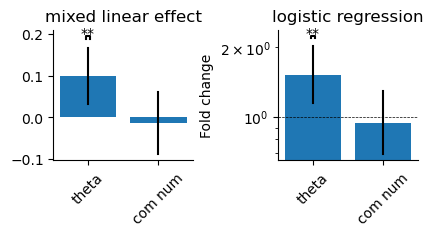

In [212]:
# 4. Create the bar graph using matplotlib

fig, axes = plt.subplots(1,2,figsize=(5, 3))

#### axis 0
coef_pd, coef_names, coef_est, pvalues, CI = model2numbers(ols_result1)
axes[0].bar(coef_names, coef_est, error_kw=dict(color='k'))
for coef_name in coef_names:
    axes[0].plot([coef_name,coef_name],[CI.loc[coef_name][0], CI.loc[coef_name][1]], color = 'k')

for coef_ind in range(len(pvalues)):
    pvalue = pvalues[coef_ind]
    if pvalue < 0.05:
        starbars.draw_annotation([(coef_ind, coef_ind, np.round(pvalue, 4))], ax = axes[0])

axes[0].set_xticks(np.arange(len(coef_names)))
axes[0].set_xticklabels(coef_names, rotation=45)
axes[0].set_title("mixed linear effect")


#### axis 1
coef_pd, coef_names, coef_est, pvalues, CI = model2numbers(logistic_result1)
coef_est = np.exp(coef_est)
coef_pd = np.exp(coef_pd)
CI = np.exp(CI)

axes[1].bar(coef_names, coef_est, error_kw=dict(color='k'))
for coef_name in coef_names:
    axes[1].plot([coef_name,coef_name],[CI.loc[coef_name][0], CI.loc[coef_name][1]], color = 'k')

for coef_ind in range(len(pvalues)):
    pvalue = pvalues[coef_ind]
    if pvalue < 0.05:
        starbars.draw_annotation([(coef_ind, coef_ind, np.round(pvalue, 4))], ax = axes[1], color = 'k')

axes[1].set_xticks(np.arange(len(coef_names)))
axes[1].set_xticklabels(coef_names, rotation=45)
axes[1].set_title("logistic regression")
axes[1].set_ylabel("Fold change")
axes[1].axhline(1,linewidth = 0.5,linestyle='dashed', color = 'k')
axes[1].set_yscale('log') 

theta_point_est = coef_pd.loc["theta"]
theta_CI = CI.loc["theta"]
print(f"Fold change of the effect of remote theta content is {theta_point_est}, with 95% bound: {theta_CI[0],theta_CI[1]}")
fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 

axes[0].spines[['right', 'top']].set_visible(False)
axes[1].spines[['right', 'top']].set_visible(False)

plt.savefig(f'extra_correctness_by_theta_GLM.pdf',dpi=300,bbox_inches='tight')

Fold change of the effect of long theta content is 1.2979512122233816, with 95% bound: (0.9302382967203473, 1.8110169783932273)


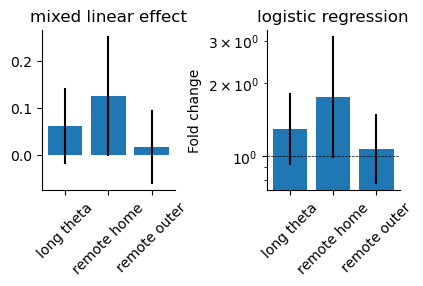

In [213]:
# 4. Create the bar graph using matplotlib

fig, axes = plt.subplots(1,2,figsize=(5, 3.5))

#### axis 0
coef_pd, coef_names, coef_est, pvalues, CI = model2numbers(ols_result2)
axes[0].bar(coef_names, coef_est, ecolor='C6')
for coef_name in coef_names:
    axes[0].plot([coef_name,coef_name],[CI.loc[coef_name][0], CI.loc[coef_name][1]], color = 'k')

for coef_ind in range(len(pvalues)):
    pvalue = pvalues[coef_ind]
    if pvalue < 0.05:
        starbars.draw_annotation([(coef_ind, coef_ind, np.round(pvalue, 4))], ax = axes[0])

axes[0].set_xticks(np.arange(len(coef_names)))
axes[0].set_xticklabels(coef_names, rotation=45)
axes[0].set_title("mixed linear effect")


#### axis 1
coef_pd, coef_names, coef_est, pvalues, CI = model2numbers(logistic_result2)
coef_est = np.exp(coef_est)
coef_pd = np.exp(coef_pd)
CI = np.exp(CI)

axes[1].bar(coef_names, coef_est)
for coef_name in coef_names:
    axes[1].plot([coef_name,coef_name],[CI.loc[coef_name][0], CI.loc[coef_name][1]], color = 'k')

for coef_ind in range(len(pvalues)):
    pvalue = pvalues[coef_ind]
    if pvalue < 0.05:
        starbars.draw_annotation([(coef_ind, coef_ind, np.round(pvalue, 4))], ax = axes[1], color = 'k')

axes[1].set_xticks(np.arange(len(coef_names)))
axes[1].set_xticklabels(coef_names, rotation=45)
axes[1].set_title("logistic regression")
axes[1].set_ylabel("Fold change")
axes[1].axhline(1,linewidth = 0.5,linestyle='dashed', color = 'k')
axes[1].set_yscale('log') 

theta_point_est = coef_pd.loc["long theta"]
theta_CI = CI.loc["long theta"]
print(f"Fold change of the effect of long theta content is {theta_point_est}, with 95% bound: {theta_CI[0],theta_CI[1]}")
fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 

axes[0].spines[['right', 'top']].set_visible(False)
axes[1].spines[['right', 'top']].set_visible(False)

plt.savefig(f'extra_correctness_by_theta_longtheta_remotetheta.pdf',dpi=300,bbox_inches='tight')